# Project SQL - BigQuery

## Pick a dataset that interests you (or multiple data sets)

Use the Open Data Sets available from Google BigQuery. You can use your own Google account or Kaggle.



## Come up with questions about your data
* What sort of information is in this dataset?
* How many records are there?
* Have the number of bitcoin transactions increased year over year?
* Does New Mexico get more or less rain now than 20 years ago?
* How many different countries (states, counties, cities, etc) have records in this data set?




## Use SQL queries to pull specific information

Like with the Chinook data base, do NOT pull all the data and then filter using DataFrame methods etc.

Write your question and then answer it using the SQL statements below.  Be sure to use guardrails ( e.g. dryrun ).



### Basic Queries


## Using usa_1910_Current for table storage stats

* Number of rows
  * 6,311,504
* Total logical bytes
  * 185.85 MB
* Active logical bytes
  * 0 B
* Long term logical bytes
  * 185.85 MB
* Current physical bytes
  * 12.05 MB
* Total physical bytes
  * 12.05 MB
* Active physical bytes
  * 0 B
* Long term physical bytes
  * 12.05 MB
* Time travel physical bytes
  * 0 B

                                        

Access Big Query big-pops account

In [1]:
from google.colab import auth
auth.authenticate_user()
from rich import print

project_id = "big-pops-501222"   # my project id

from google.cloud import bigquery
client = bigquery.Client(project=project_id)
print("[green]Connected to project:[/green]", project_id)


Connected to project: big-pops-501222

### Dry run no charge = False.  If query exceeds the 1.0 GB guardrail the query will error out, and return no results.  Use Rich text for fun.

## Used Select *(wildcard) to view table From `bigquery-public-data.usa_names.usa_1910_current`

In [2]:
def dry_run(query):  # My function called dry run with the SQL  string 'query'
    """Estimate bytes scanned WITHOUT running the query. No charge."""
    job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)  # dry= true estimates size of query and use_query_cache = False does not use a cached estimate of the size
    job = client.query(query, job_config=job_config)  # Google BigQuery totals the byte cost but does not charge me
    gb = job.total_bytes_processed / 1e9  # total bytes divided by 1 billion resutl will be in GB
    print(f"[black on bright_white]This query will scan [/] {job.total_bytes_processed:,} bytes ({gb:.4f} GB)" )  # prints and formmats job.total_bytes_processed and gb.4f
    return job.total_bytes_processed

def run_sql(query, max_gb=1.0):
    cfg = bigquery.QueryJobConfig(maximum_bytes_billed=int(max_gb * 1e9))
    return client.query(query, job_config=cfg).to_dataframe()

# query runs
print("="*55)

query = """
    SELECT *
    FROM `bigquery-public-data.usa_names.usa_1910_current`

    LIMIT 10
"""

dry_run(query)          # check bytes — should be tiny

print("="*55)
df = run_sql(query)   # then run
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,state,gender,year,name,number
0,AK,F,1910,Mary,14
1,AK,F,1910,Annie,12
2,AK,F,1910,Anna,10
3,AK,F,1910,Margaret,8
4,AK,F,1910,Helen,7
5,AK,F,1910,Elsie,6
6,AK,F,1910,Lucy,6
7,AK,F,1910,Dorothy,5
8,AK,F,1911,Mary,12
9,AK,F,1911,Margaret,7


Used Select with name, gender, year, and number from `bigquery-public-data.usa_names.usa_1910_current` List of names, females ,and total name counts  -  ran and got 5 columns had to press shift + enteer to get this cell to run without getting the state results.  

In [3]:
query = """

  SELECT name, gender, year, number
    FROM `bigquery-public-data.usa_names.usa_1910_current`
  LIMIT 10
"""
print("="*55)


dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  169,627,794 bytes (0.1696 GB)

=======================================================

,name,gender,year,number
0,Mary,F,1910,14
1,Annie,F,1910,12
2,Anna,F,1910,10
3,Margaret,F,1910,8
4,Helen,F,1910,7
5,Elsie,F,1910,6
6,Lucy,F,1910,6
7,Dorothy,F,1910,5
8,Mary,F,1911,12
9,Margaret,F,1911,7


#### WHERE


### WHERE to call gender female, also select to call column name, gender, year, number of persons with that name, and state.  Names that were less than five in the data set are not listed due to privacy.  

In [4]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE gender = 'F'
    LIMIT 30
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Mary,F,1910,14,AK
1,Annie,F,1910,12,AK
2,Anna,F,1910,10,AK
3,Margaret,F,1910,8,AK
4,Helen,F,1910,7,AK
5,Elsie,F,1910,6,AK
6,Lucy,F,1910,6,AK
7,Dorothy,F,1910,5,AK
8,Mary,F,1911,12,AK
9,Margaret,F,1911,7,AK


#### AND


Using WHERE to call gender column = Female AND to call state is NM is female and is state NM the use of and where must be true to return results.

In [5]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE gender = 'F' AND state = 'NM'
    LIMIT 30
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Mary,F,1910,98,NM
1,Maria,F,1910,40,NM
2,Margaret,F,1910,38,NM
3,Josephine,F,1910,35,NM
4,Helen,F,1910,26,NM
5,Juanita,F,1910,26,NM
6,Rosa,F,1910,20,NM
7,Frances,F,1910,19,NM
8,Emma,F,1910,18,NM
9,Ruth,F,1910,16,NM


#### OR


Conditions must be on both sides of the OR to return results in this case state = "NM" or state = "AZ" or state = "Texas".  Didn't show NM, TX , set  LIMIT 30.

In [6]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' OR state = 'AZ' OR state =  'TX'
    LIMIT 30
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Mary,F,1910,74,AZ
1,Maria,F,1910,29,AZ
2,Alice,F,1910,27,AZ
3,Margaret,F,1910,19,AZ
4,Helen,F,1910,18,AZ
5,Frances,F,1910,17,AZ
6,Dorothy,F,1910,16,AZ
7,Elizabeth,F,1910,15,AZ
8,Josephine,F,1910,15,AZ
9,Ruth,F,1910,15,AZ


#### LIKE (with % or _ wildcard)


#### Use LIKE AND % to find ny great grandmother's name = Ursula

In [39]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE name LIKE 'Anne%' AND state = 'NM'
    LIMIT 70
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Anne,F,1915,8,NM
1,Anne,F,1916,5,NM
2,Anne,F,1918,6,NM
3,Anne,F,1921,12,NM
4,Anne,F,1923,6,NM
...,...,...,...,...,...
65,Annette,F,1971,43,NM
66,Anne,F,1971,16,NM
67,Annette,F,1972,40,NM
68,Anne,F,1972,14,NM


#### BETWEEN


Using Between for a range of dates from 1950 to 1969 - not dates returned on 1969 because of limit 30

In [8]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE year BETWEEN 1950 AND 1969
      AND state = 'NM'
    LIMIT 30
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Mary,F,1950,512,NM
1,Linda,F,1950,351,NM
2,Patricia,F,1950,243,NM
3,Barbara,F,1950,179,NM
4,Gloria,F,1950,159,NM
5,Margaret,F,1950,127,NM
6,Susan,F,1950,118,NM
7,Elizabeth,F,1950,117,NM
8,Maria,F,1950,112,NM
9,Nancy,F,1950,111,NM


#### LIMIT



### Set LIMIT 5 got back five rows with various female names - if this table is accurate the year my mother was born 177 people were given the same name.

In [9]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' AND year =  1952
    LIMIT 5
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Mary,F,1952,507,NM
1,Patricia,F,1952,287,NM
2,Linda,F,1952,284,NM
3,Deborah,F,1952,193,NM
4,Barbara,F,1952,177,NM


In [36]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' AND year =  1972
    LIMIT 30
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Jennifer,F,1972,274,NM
1,Michelle,F,1972,204,NM
2,Melissa,F,1972,151,NM
3,Lisa,F,1972,140,NM
4,Angela,F,1972,113,NM
5,Kimberly,F,1972,108,NM
6,Stephanie,F,1972,99,NM
7,Amy,F,1972,97,NM
8,Elizabeth,F,1972,85,NM
9,Monica,F,1972,83,NM


### Sorting and Grouping


#### ORDER BY


### Use ORDER BY DESC and LIMIT 30 to find the top 30 by count for year 1969 and can not use '1969' YEARS ARE INTS NOT STR

In [49]:
query = """
    SELECT name, gender, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' AND year = 1969 AND name = 'Charles'
    ORDER BY number DESC
    LIMIT 30;
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  194,873,810 bytes (0.1949 GB)

=======================================================

,name,gender,year,number,state
0,Charles,M,1969,110,NM


#### DISTINCT


USE DISTINCT ON state = 50 states in THE UNION plus the District of Columbia.

In [11]:
query = """
    SELECT COUNT(DISTINCT state) AS num_states
    FROM `bigquery-public-data.usa_names.usa_1910_current`
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  25,246,016 bytes (0.0252 GB)

=======================================================

,num_states
0,51


#### GROUP BY



### Use GROUP BY to show number of rows per AZ, NM, and TX with no LIMIT condition set.

In [12]:
query = """
    SELECT state, COUNT(*) AS rows_per_state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' OR state = 'AZ' OR state = 'TX'
    GROUP BY state
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  25,246,016 bytes (0.0252 GB)

=======================================================

,state,rows_per_state
0,AZ,122085
1,NM,77755
2,TX,368987


### Aggregates


#### MAX


Use MAX for NM on biggest count in names can add a conditon AND name LIKE 'juan' to check a specific name and count.

In [13]:
query = """
    SELECT MAX(number) AS biggest_count
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  75,738,048 bytes (0.0757 GB)

=======================================================

,biggest_count
0,589


Use ORDER BY DESC, Limit 1 and result shows name plus count

In [14]:
query = """
    SELECT name, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    ORDER BY number DESC
    LIMIT 1
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  175,939,298 bytes (0.1759 GB)

=======================================================

,name,year,number,state
0,Mary,1947,589,NM


#### MIN


### Use Min on name to find the min name in NM

In [15]:
query = """
    SELECT MIN(name) AS smallest_count
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'

"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  74,955,234 bytes (0.0750 GB)

=======================================================

,smallest_count
0,Aaden


### Used ORDER BY ASC for name with 5 in number.

In [16]:
query = """
    SELECT name, year, number, state
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    ORDER BY number ASC
    LIMIT 1
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  175,939,298 bytes (0.1759 GB)

=======================================================

,name,year,number,state
0,Aurora,1910,5,NM


#### SUM


### Returned total births since 1910 with names reproted more than five times.  So this is not the total of all births in NM names that were recorded.A name recorded once or twice are not listed in the name tables due to privacy.

In [17]:
query = """
    SELECT SUM(number) AS total_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  75,738,048 bytes (0.0757 GB)

=======================================================

,total_births
0,1752061


#### AVG


### Looking at average_births per year using WHERE, AND , BETWEEN, GROUP BY and ORDER BY.   Years selected 1910 - 1945.   The average birth increased during the war.

In [18]:
query = """
    SELECT year, AVG(number) AS avg_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' AND year BETWEEN 1910 AND 1950
    GROUP BY year
    ORDER BY year
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  126,230,080 bytes (0.1262 GB)

=======================================================

,year,avg_births
0,1910,11.561151
1,1911,11.071429
2,1912,12.381818
3,1913,12.751092
4,1914,13.823970
5,1915,15.174286
6,1916,16.101408
7,1917,15.386139
8,1918,17.191283
9,1919,16.309645


#### COUNT



### Use count to total all births in 1969 that were male

In [19]:
query = """
    SELECT SUM(number) AS total_male_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM' AND gender = 'M' AND year = 1969
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  145,164,592 bytes (0.1452 GB)

=======================================================

,total_male_births
0,9295


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



=======================================================

This query will scan  125,447,266 bytes (0.1254 GB)

=======================================================

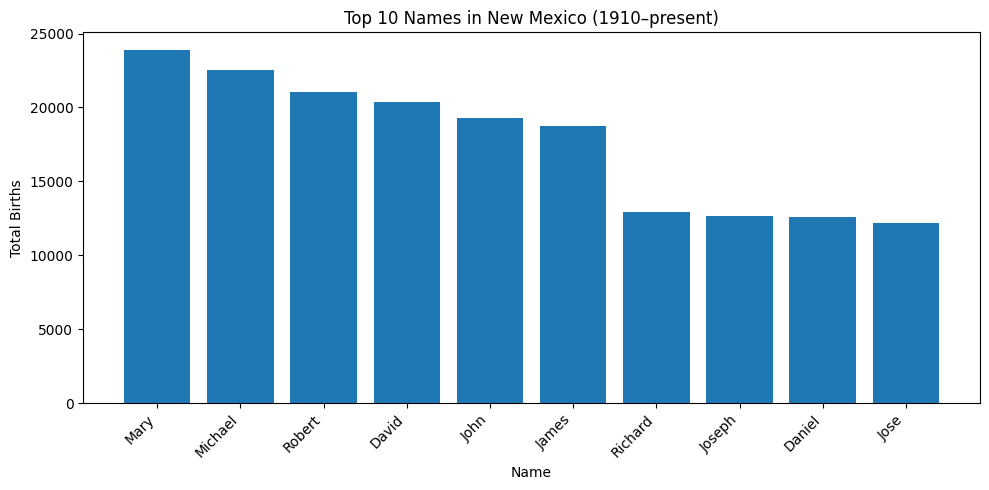

In [20]:
query = """
    SELECT name, SUM(number) AS total_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    GROUP BY name
    ORDER BY total_births DESC
    LIMIT 10
"""
print("="*55)
dry_run(query)
top_names = run_sql(query)
print("="*55)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(top_names['name'], top_names['total_births'])
plt.title('Top 10 Names in New Mexico (1910–present)')
plt.xlabel('Name')
plt.ylabel('Total Births')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=======================================================

This query will scan  126,230,080 bytes (0.1262 GB)

=======================================================

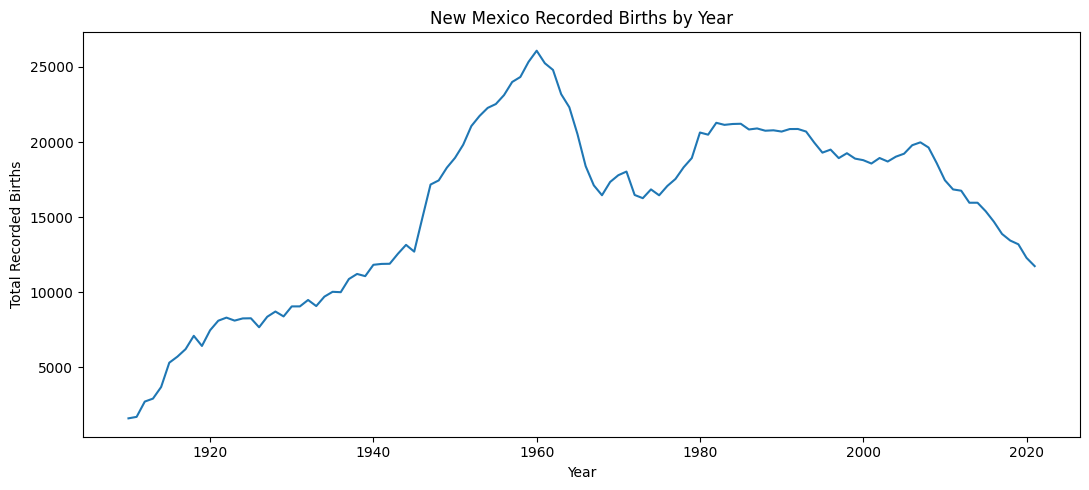

In [21]:
query = """
    SELECT year, SUM(number) AS total_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    GROUP BY year
    ORDER BY year
"""
print("="*55)
dry_run(query)
by_year = run_sql(query)
print("="*55)

plt.figure(figsize=(11, 5))
plt.plot(by_year['year'], by_year['total_births'])
plt.title('New Mexico Recorded Births by Year')
plt.xlabel('Year')
plt.ylabel('Total Recorded Births')
plt.tight_layout()
plt.show()

### AI Generated plot and Markdown

Plotly (interactive plots). import plotly.express as px. px.bar() / px.line() build hover-able, zoomable charts — better than static matplotlib for presentations. Same rule: SQL aggregates first (SUM + GROUP BY), Plotly just draws the small result. Interactive = good for the final presentation.

In [22]:
import plotly.express as px

query = """
    SELECT name, SUM(number) AS total_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    GROUP BY name
    ORDER BY total_births DESC
    LIMIT 15
"""
print("="*55)
dry_run(query)
top_names = run_sql(query)
print("="*55)

fig = px.bar(top_names,
             x='name',
             y='total_births',
             title='Top 15 Names in New Mexico (1910–present)',
             labels={'name': 'Name', 'total_births': 'Total Births'})
fig.show()

=======================================================

This query will scan  125,447,266 bytes (0.1254 GB)

=======================================================

In [23]:
query = """
    SELECT year, SUM(number) AS total_births
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    GROUP BY year
    ORDER BY year
"""
print("="*55)
dry_run(query)
by_year = run_sql(query)
print("="*55)

fig = px.line(by_year,
              x='year',
              y='total_births',
              title='New Mexico Recorded Births by Year',
              labels={'year': 'Year', 'total_births': 'Total Recorded Births'},
              markers=True)
fig.show()

=======================================================

This query will scan  126,230,080 bytes (0.1262 GB)

=======================================================

## EXTRA CREDIT:

#### Use a query that joins two tables.


### This single table joins names that stayed popular in NM between 1970 and 2010 it uses CTE.

In [24]:
query = """
    WITH y1970 AS (
        SELECT name, SUM(number) AS births_1970
        FROM `bigquery-public-data.usa_names.usa_1910_current`
        WHERE state = 'NM' AND year = 1970
        GROUP BY name
    ),
    y2010 AS (
        SELECT name, SUM(number) AS births_2010
        FROM `bigquery-public-data.usa_names.usa_1910_current`
        WHERE state = 'NM' AND year = 2010
        GROUP BY name
    )
    SELECT a.name, a.births_1970, b.births_2010
    FROM y1970 a
    JOIN y2010 b ON a.name = b.name
    ORDER BY b.births_2010 DESC
    LIMIT 20
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  175,939,298 bytes (0.1759 GB)

=======================================================

,name,births_1970,births_2010
0,Jacob,10,134
1,Michael,376,125
2,Sophia,14,124
3,Joshua,17,119
4,Gabriel,45,116
5,Anthony,124,112
6,Daniel,145,111
7,Angel,6,105
8,Julian,16,95
9,David,290,93


#### The least names selected at birth in NM from 1910 to current- the names were recorded with a minimum of 5 times. Names reorded less then 5 times are not used in the table - so can not determine if the name was unpopular or the prefrence was to name a child with a rare name.

In [25]:
query = """
    WITH name_totals AS (
        SELECT name, SUM(number) AS total_births
        FROM `bigquery-public-data.usa_names.usa_1910_current`
        WHERE state = 'NM' AND year BETWEEN 1970 AND 2010
        GROUP BY name
    )
    SELECT name, total_births
    FROM name_totals
    ORDER BY total_births ASC
    LIMIT 20
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  175,939,298 bytes (0.1759 GB)

=======================================================

,name,total_births
0,Therese,5
1,Patty,5
2,Mellisa,5
3,Dee,5
4,Corine,5
5,Rosita,5
6,Roxane,5
7,Shonna,5
8,Karin,5
9,Inez,5


#### Make a model to see if you can predict something


Determining exact time frame for model - wanted to check the actual time frame because the table says 1910 to current.  It is actually 1910 to 2021.

In [26]:
query = """
    SELECT MIN(year) AS earliest, MAX(year) AS latest
    FROM `bigquery-public-data.usa_names.usa_1910_current`
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  50,492,032 bytes (0.0505 GB)

=======================================================

,earliest,latest
0,1910,2021


### This classification of structured data will use GNB model.  First check the shape and head of the table - predict gender M/F the target y  and features x = length and last letter to determine if last letter of name predicts gender. Use stratify = y to balance the train/test split. Use dummy classifier baseline to see if the prediction model can beat the dummy score and determine if the model is making an actual prediction or just guessing, dummy score is the is the most frequent class in y which is female.  

In [27]:
query = """
    SELECT name, gender, SUM(number) AS total
    FROM `bigquery-public-data.usa_names.usa_1910_current`
    WHERE state = 'NM'
    GROUP BY name, gender
"""
print("="*55)
dry_run(query)
names_df = run_sql(query)
print("="*55)
print(names_df.shape)
print("="*55)

names_df.head()

=======================================================

This query will scan  144,381,778 bytes (0.1444 GB)

=======================================================

(3652, 3)

=======================================================

,name,gender,total
0,Mary,F,23813
1,Maria,F,8823
2,Margaret,F,5507
3,Josephine,F,2706
4,Helen,F,4042


### Feature engineering not feature scaling — pull signal out of the name string and last letter turning it into numbers. Signal is the pattern in the data and noise is the 'pattern-less' data, signal in X (features) tells us something about 'y' our target. The model can work with by creating name_length and one hot encode last letter to 0 or 1 , becoming many columns and determining if we can predict gender by the binary unit of 0 = male, 1 = female.

In [28]:

names_df['name_length'] = names_df['name'].str.len()
names_df['last_letter'] = names_df['name'].str[-1].str.lower()
print("="*55)
names_df.head()

=======================================================

,name,gender,total,name_length,last_letter
0,Mary,F,23813,4,y
1,Maria,F,8823,5,a
2,Margaret,F,5507,8,t
3,Josephine,F,2706,9,e
4,Helen,F,4042,5,n


In [29]:
import pandas as pd


# One-hot encode the last letter (text → 0/1 columns)
X = pd.get_dummies(names_df[['name_length', 'last_letter']],
                   columns=['last_letter'],
                   drop_first=True)

# Target: gender
y = (names_df['gender'] == 'F').astype(int)   # 1 = Female, 0 = Male
print("="*25)
print("Features:", X.shape[1], "| Rows:", X.shape[0])
print("Female:", y.sum(), "| Male:", (y==0).sum())
print("="*25)

=========================

Features: 23 | Rows: 3652

Female: 2226 | Male: 1426

=========================

### Fit GNB with dummy baseline to test against prediction, does the last letter in a name indicate the gender = female? The Dummy baseline will always select for female about 60% of the time (look at output). The data is mostly females and is imbalanced, 2226 to 1426 males.   target mostly females in the data set - see if the model can predict without selecting for the over represented values using stratify = y to keep the ratio across train and test in sklearn.  Stratify = y is not used in Regression Modeling.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score





X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Dummy baseline — most frequent class (will guess Female ~61%)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print("[green]Dummy accuracy: [/green]", accuracy_score(y_test, dummy.predict(X_test)))
print("="*35)
# Real model
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print("GNB accuracy:", accuracy_score(y_test, gnb.predict(X_test)))
print("="*35)

Dummy accuracy:  0.6089813800657174

===================================

GNB accuracy: 0.696604600219058

===================================

The model was able to learn a pattern and predict better than the dummy accuracy 0.6089813800657174 vs. GNB accuracy: 0.696604600219058 which indicates that the last letter in a name predicts gender = female. Our test showed good results.

#### Come up with something else cool to do with your data


### How many names were unisex in the data set.  Used GROUP BY name, and SUM births by gender, if name was not shared in the gender, they were excluded from the total > 100 in name count. Used WHERE only for NM for the total0 time period of the table.

In [31]:
query = """
    WITH name_gender AS (
        SELECT name,
               SUM(CASE WHEN gender = 'M' THEN number ELSE 0 END) AS male_births,
               SUM(CASE WHEN gender = 'F' THEN number ELSE 0 END) AS female_births
        FROM `bigquery-public-data.usa_names.usa_1910_current`
        WHERE state = 'NM'
        GROUP BY name
    )
    SELECT name, male_births, female_births
    FROM name_gender
    WHERE male_births > 100 AND female_births > 100
    ORDER BY (male_births + female_births) DESC
    LIMIT 20
"""
print("="*55)
dry_run(query)
df = run_sql(query)
print("="*55)
df

=======================================================

This query will scan  144,381,778 bytes (0.1444 GB)

=======================================================

,name,male_births,female_births
0,Angel,2445,1176
1,Jordan,2326,922
2,Alexis,475,2409
3,Terry,1722,690
4,Kelly,505,1718
5,Leslie,431,1712
6,Shannon,232,1708
7,Shawn,1776,128
8,Taylor,553,1350
9,Jamie,360,1452
